FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller,acf,pacf
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.tsa.api as smt

In [56]:
pd.read_csv("exchange_rate.csv")

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [57]:
Er= pd.read_csv('exchange_rate.csv',parse_dates=True, index_col='date')
Er.head()

,Ex_rate
date,
01-01-1990 00:00,0.7855
02-01-1990 00:00,0.7818
03-01-1990 00:00,0.7867
04-01-1990 00:00,0.7860
05-01-1990 00:00,0.7849


In [58]:
Er.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7588 entries, 01-01-1990 00:00 to 10-10-2010 00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6+ KB


In [59]:
# Check missing values
Er.isnull().sum()

Ex_rate    0
dtype: int64

In [60]:
# Checking for duplicates
Er.duplicated().sum()

np.int64(2258)

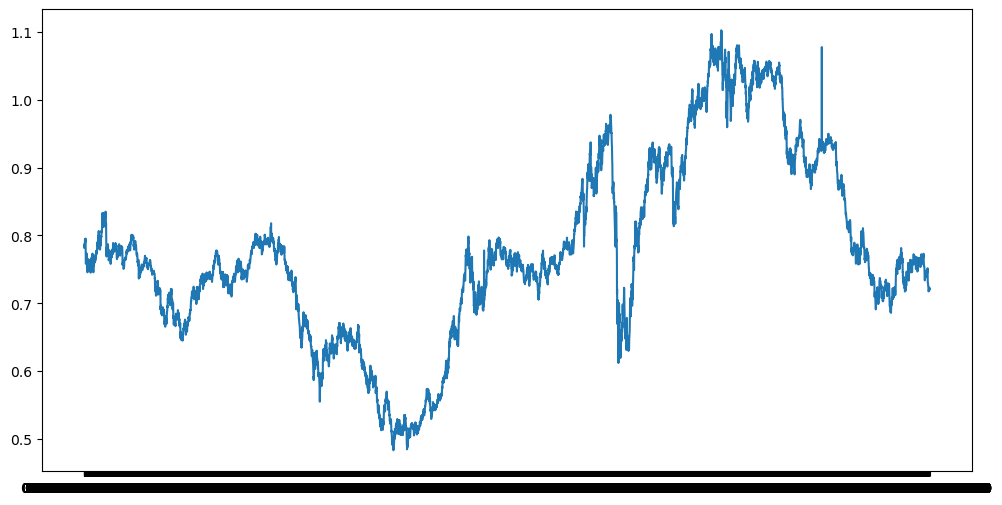

In [61]:
plt.figure(figsize=(12,6))
plt.plot(Er)
plt.show()

In [68]:
result= seasonal_decompose(Er['Ex_rate'],model='multiplicative',period=365)

(array([-1000.,     0.,  1000.,  2000.,  3000.,  4000.,  5000.,  6000.,
         7000.,  8000.]),
 [Text(-1000.0, 0, '15-01-2008 00:00'),
  Text(0.0, 0, '01-01-1990 00:00'),
  Text(1000.0, 0, '27-09-1992 00:00'),
  Text(2000.0, 0, '24-06-1995 00:00'),
  Text(3000.0, 0, '20-03-1998 00:00'),
  Text(4000.0, 0, '14-12-2000 00:00'),
  Text(5000.0, 0, '10-09-2003 00:00'),
  Text(6000.0, 0, '06-06-2006 00:00'),
  Text(7000.0, 0, '02-03-2009 00:00'),
  Text(8000.0, 0, '')])

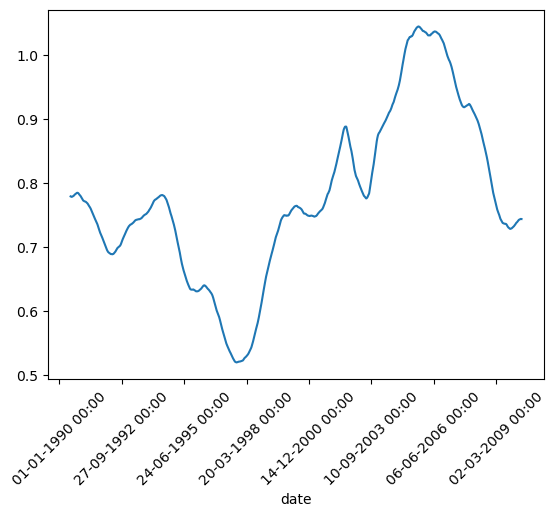

In [69]:
result.trend.plot()
plt.xticks(rotation=45)

(array([-1000.,     0.,  1000.,  2000.,  3000.,  4000.,  5000.,  6000.,
         7000.,  8000.]),
 [Text(-1000.0, 0, '15-01-2008 00:00'),
  Text(0.0, 0, '01-01-1990 00:00'),
  Text(1000.0, 0, '27-09-1992 00:00'),
  Text(2000.0, 0, '24-06-1995 00:00'),
  Text(3000.0, 0, '20-03-1998 00:00'),
  Text(4000.0, 0, '14-12-2000 00:00'),
  Text(5000.0, 0, '10-09-2003 00:00'),
  Text(6000.0, 0, '06-06-2006 00:00'),
  Text(7000.0, 0, '02-03-2009 00:00'),
  Text(8000.0, 0, '')])

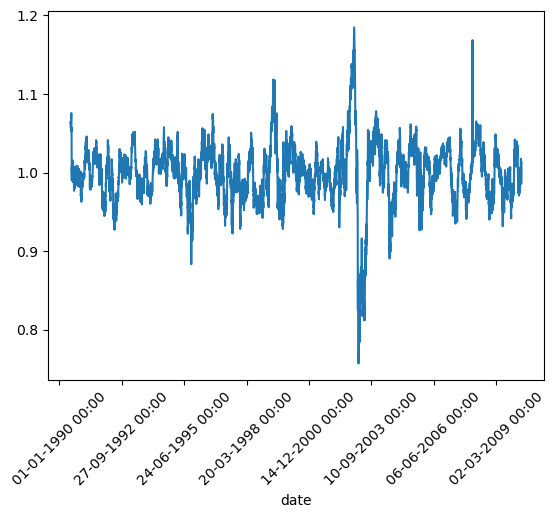

In [70]:
result.resid.plot()
plt.xticks(rotation=45)

In [ ]:
Noise 

(array([-1000.,     0.,  1000.,  2000.,  3000.,  4000.,  5000.,  6000.,
         7000.,  8000.]),
 [Text(-1000.0, 0, '15-01-2008 00:00'),
  Text(0.0, 0, '01-01-1990 00:00'),
  Text(1000.0, 0, '27-09-1992 00:00'),
  Text(2000.0, 0, '24-06-1995 00:00'),
  Text(3000.0, 0, '20-03-1998 00:00'),
  Text(4000.0, 0, '14-12-2000 00:00'),
  Text(5000.0, 0, '10-09-2003 00:00'),
  Text(6000.0, 0, '06-06-2006 00:00'),
  Text(7000.0, 0, '02-03-2009 00:00'),
  Text(8000.0, 0, '')])

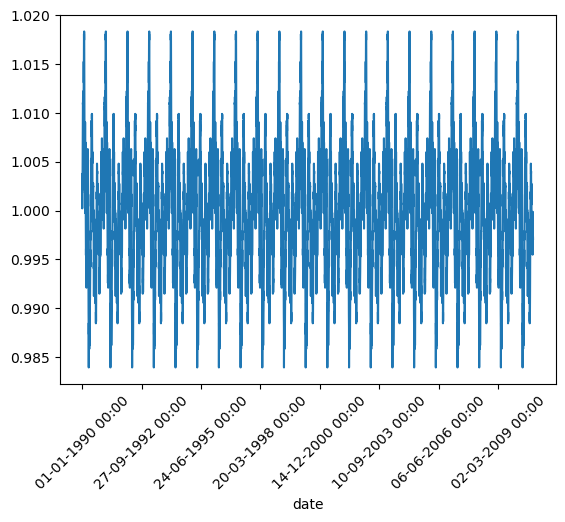

In [71]:
result.seasonal.plot()
plt.xticks(rotation=45)

In [72]:
Er= pd.read_csv('exchange_rate.csv',index_col='date',parse_dates=True)

In [73]:
Er.head()

,Ex_rate
date,
01-01-1990 00:00,0.7855
02-01-1990 00:00,0.7818
03-01-1990 00:00,0.7867
04-01-1990 00:00,0.7860
05-01-1990 00:00,0.7849


In [74]:
def test_stationarity(timeseries):

    #Calculate rolling mean and rolling standard deviation
    rolmean = timeseries.rolling(window = 12).mean()
    rolstd = timeseries.rolling(window = 12).std()

    original = plt.plot(timeseries, color = 'blue', label = 'Original')
    mean = plt.plot(rolmean, color = 'red', label = 'Rolling Mean')
    std = plt.plot(rolstd, color = 'green', label = 'Rolling Std')
    plt.legend(loc='best')


    print('Results of Dickey-Fuller Test :\n')
    df_test = adfuller(timeseries)
    my_output = pd.Series(df_test[0:4], index =['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for i,j in df_test[4].items():
        my_output['Critical Value (%s)'%i] =j
    print(my_output)

Results of Dickey-Fuller Test :

Test Statistic                   -1.664994
p-value                           0.449233
#Lags Used                        1.000000
Number of Observations Used    7586.000000
Critical Value (1%)              -3.431212
Critical Value (5%)              -2.861921
Critical Value (10%)             -2.566973
dtype: float64


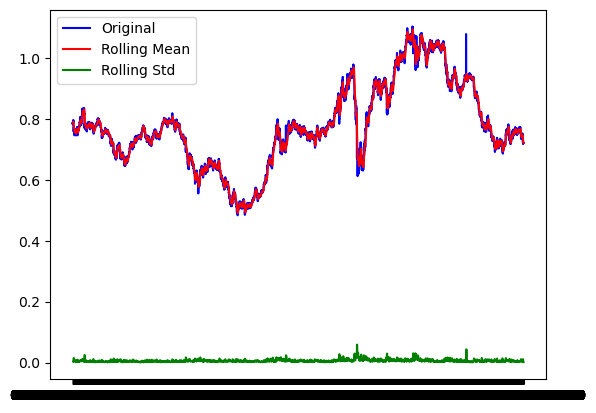

In [75]:
test_stationarity(Er['Ex_rate'])

In [76]:
#df_diff = Er['Ex_rate'].diff().dropna()
Er['Er_Diff']= Er['Ex_rate']-Er['Ex_rate'].shift(1)
Er.dropna(inplace=True)
Er

,Ex_rate,Er_Diff
date,,
02-01-1990 00:00,0.781800,-0.003700
03-01-1990 00:00,0.786700,0.004900
04-01-1990 00:00,0.786000,-0.000700
05-01-1990 00:00,0.784900,-0.001100
06-01-1990 00:00,0.786600,0.001700
...,...,...
06-10-2010 00:00,0.718494,-0.000207
07-10-2010 00:00,0.721839,0.003345
08-10-2010 00:00,0.723197,0.001358


Results of Dickey-Fuller Test :

Test Statistic                  -99.393431
p-value                           0.000000
#Lags Used                        0.000000
Number of Observations Used    7586.000000
Critical Value (1%)              -3.431212
Critical Value (5%)              -2.861921
Critical Value (10%)             -2.566973
dtype: float64


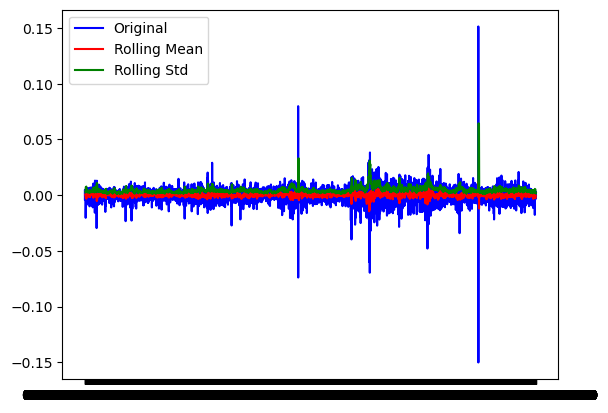

In [78]:
test_stationarity(Er['Er_Diff'])

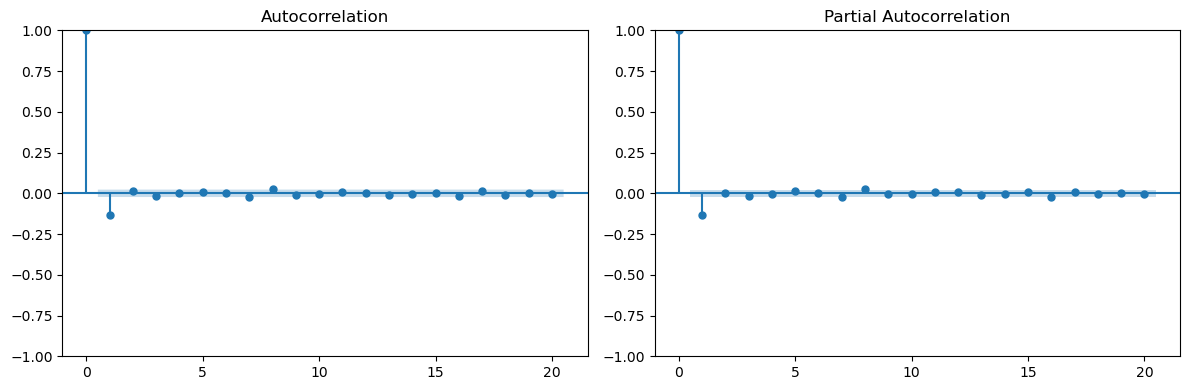

In [86]:
fig, axes = plt.subplots(1, 2)
fig.set_figwidth(12)
fig.set_figheight(4)
smt.graphics.plot_acf(Er['Er_Diff'], lags=20, ax=axes[0])
smt.graphics.plot_pacf(Er['Er_Diff'], lags=20, ax=axes[1])
plt.tight_layout()

In [81]:
import warnings
warnings.filterwarnings('ignore')
model = ARIMA(Er['Ex_rate'], order=(1,1,1))

In [82]:
Er.columns

Index(['Ex_rate', 'Er_Diff'], dtype='object')

In [83]:
Er.head()

,Ex_rate,Er_Diff
date,,
02-01-1990 00:00,0.7818,-0.0037
03-01-1990 00:00,0.7867,0.0049
04-01-1990 00:00,0.7860,-0.0007
05-01-1990 00:00,0.7849,-0.0011
06-01-1990 00:00,0.7866,0.0017


In [90]:
# Model Fitting
result= model.fit()
# 	Forecasting: 
result.forecast(20)

7587    0.720826
7588    0.720826
7589    0.720826
7590    0.720826
7591    0.720826
7592    0.720826
7593    0.720826
7594    0.720826
7595    0.720826
7596    0.720826
7597    0.720826
7598    0.720826
7599    0.720826
7600    0.720826
7601    0.720826
7602    0.720826
7603    0.720826
7604    0.720826
7605    0.720826
7606    0.720826
Name: predicted_mean, dtype: float64

In [91]:
Er['predicted']=result.predict()

In [92]:
Er.head()

,Ex_rate,Er_Diff,predicted
date,,,
02-01-1990 00:00,0.7818,-0.0037,0.000000
03-01-1990 00:00,0.7867,0.0049,0.781800
04-01-1990 00:00,0.7860,-0.0007,0.786056
05-01-1990 00:00,0.7849,-0.0011,0.786089
06-01-1990 00:00,0.7866,0.0017,0.785045


In [93]:
forecast=result.forecast(20)
forecast

7587    0.720826
7588    0.720826
7589    0.720826
7590    0.720826
7591    0.720826
7592    0.720826
7593    0.720826
7594    0.720826
7595    0.720826
7596    0.720826
7597    0.720826
7598    0.720826
7599    0.720826
7600    0.720826
7601    0.720826
7602    0.720826
7603    0.720826
7604    0.720826
7605    0.720826
7606    0.720826
Name: predicted_mean, dtype: float64

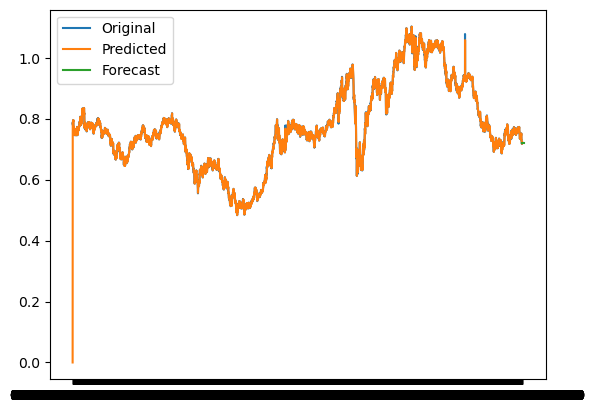

In [106]:
plt.plot(Er['Ex_rate'],label='Original')
plt.plot(Er['predicted'],label='Predicted')
plt.plot(forecast,label='Forecast')
plt.legend()
plt.show()

In [99]:
from sklearn.metrics import mean_absolute_percentage_error,mean_squared_error,mean_absolute_error

In [103]:
mean_absolute_error(Er['Ex_rate'],Er['predicted'])

0.00379546127226557

In [104]:
mean_squared_error(Er['Ex_rate'],Er['predicted'])

0.00011651556649649878

In [105]:
mean_absolute_percentage_error(Er['Ex_rate'],Er['predicted'])*100

0.49514654415458687

In [ ]:
ARIMA Evaluation Metrics

MAE (Mean Absolute Error) ≈ 0.0038

MSE (Mean Squared Error) ≈ 0.000116

MAPE (Mean Absolute Percentage Error) ≈ 0.495 %

1.Mean Absolute Error (MAE ≈ 0.0038)

On average, the ARIMA model’s forecast deviates from the actual exchange rate by about 0.0038 units.

Interpretation
Indicates high forecasting accuracy

2.Mean Squared Error (MSE ≈ 0.000116)

Meaning :Penalizes larger errors more heavily.

Interpretation

Very low MSE → no large forecast misses

Confirms predictions are stable and consistent

ARIMA is not producing extreme outliers

Strong and reliable model

3.Mean Absolute Percentage Error (MAPE ≈ 0.495%)

Meaning
Average percentage deviation between actual and predicted values.

Interpretation

Less than 1% error